In [1]:
import numpy as np
import pandas as pd

# ---------------------------
# Simulation parameters
# ---------------------------
PLANE_SIZE = 5000.0  # meters (square plane: 0..5000 in both x and y)
N_BACKGROUND = 100
N_GROUPS = 10
POINTS_PER_GROUP = 10
POINT_SPACING = 10.0  # meters
LOS_MIN, LOS_MAX = -50.0, 50.0  # m/s

# Fixed sensor (single dwell)
x_sensor = 0.0
y_sensor = 0.0
z_sensor = 1000.0

# Reproducibility
rng = np.random.default_rng(20251112)

# ---------------------------
# Background points (label = 0)
# ---------------------------
# Uniformly distributed across the plane [0, 5000] x [0, 5000]
background_x = rng.uniform(0.0, PLANE_SIZE, N_BACKGROUND)
background_y = rng.uniform(0.0, PLANE_SIZE, N_BACKGROUND)
background_v = rng.uniform(LOS_MIN, LOS_MAX, N_BACKGROUND)
background_label = np.zeros(N_BACKGROUND, dtype=int)

# ---------------------------
# Line group points (label = 1)
# ---------------------------
# Each group: 10 points along a line, spaced 10 m, single LOS velocity per group,
# heading uniformly in [0, 360) degrees. Ensure points remain within the plane by
# sampling group centers within a 45 m margin on all sides.

t_values = (np.arange(POINTS_PER_GROUP) - (POINTS_PER_GROUP - 1)/2.0) * POINT_SPACING  # centered offsets
half_extent = (POINTS_PER_GROUP - 1) * POINT_SPACING / 2.0  # 45 m for 10 points at 10 m spacing

line_x_all = []
line_y_all = []
line_v_all = []
line_label_all = []

for _ in range(N_GROUPS):
    # Heading in radians
    heading_deg = rng.uniform(0.0, 359.9)
    heading_rad = np.deg2rad(heading_deg)
    ux, uy = np.cos(heading_rad), np.sin(heading_rad)

    # Group center sampled with a fixed margin so all points stay within [0, PLANE_SIZE]
    margin = half_extent  # safe for any angle since |ux|, |uy| <= 1
    cx = rng.uniform(margin, PLANE_SIZE - margin)
    cy = rng.uniform(margin, PLANE_SIZE - margin)

    # Points for this group
    x_line = cx + t_values * ux
    y_line = cy + t_values * uy

    # Single LOS velocity for the group
    v_group = rng.uniform(LOS_MIN, LOS_MAX)
    v_line = np.full(POINTS_PER_GROUP, v_group)

    # Collect
    line_x_all.append(x_line)
    line_y_all.append(y_line)
    line_v_all.append(v_line)
    line_label_all.append(np.ones(POINTS_PER_GROUP, dtype=int))

# Concatenate group arrays
line_x_all = np.concatenate(line_x_all)
line_y_all = np.concatenate(line_y_all)
line_v_all = np.concatenate(line_v_all)
line_label_all = np.concatenate(line_label_all)

# ---------------------------
# Assemble full DataFrame
# ---------------------------
# Sensor columns repeat per row
n_total = N_BACKGROUND + N_GROUPS * POINTS_PER_GROUP
x_sensor_col = np.full(n_total, x_sensor)
y_sensor_col = np.full(n_total, y_sensor)
z_sensor_col = np.full(n_total, z_sensor)

# Targets
x_target_all = np.concatenate([background_x, line_x_all])
y_target_all = np.concatenate([background_y, line_y_all])
los_all = np.concatenate([background_v, line_v_all])
label_all = np.concatenate([background_label, line_label_all])

# Build DataFrame with required column order
cols = [
    'x_sensor', 'y_sensor', 'z_sensor',
    'x_target', 'y_target', 'LOS_Velocity', 'label'
]

df = pd.DataFrame({
    'x_sensor': x_sensor_col,
    'y_sensor': y_sensor_col,
    'z_sensor': z_sensor_col,
    'x_target': x_target_all,
    'y_target': y_target_all,
    'LOS_Velocity': los_all,
    'label': label_all,
})[cols]

# ---------------------------
# Save CSV
# ---------------------------
# We cannot write to your Windows OneDrive path from this environment.
# We'll save the file locally with the same filename so you can download/move it.
local_filename = 'C:/Users/charlie.burgwardt/OneDrive - NV5/GMTI/Data/simulation_2.csv'  # keeping your requested filename (typo preserved)
df.to_csv(local_filename, index=False)

print(df.head().to_string(index=False))

 x_sensor  y_sensor  z_sensor    x_target    y_target  LOS_Velocity  label
      0.0       0.0    1000.0 4384.178627 3233.194768    -27.942731      0
      0.0       0.0    1000.0 3786.754179 2468.116052     36.135597      0
      0.0       0.0    1000.0  473.061422  795.230593     33.412287      0
      0.0       0.0    1000.0 1042.941141 4378.866629     -4.286600      0
      0.0       0.0    1000.0 1382.187563  394.063297    -35.266255      0


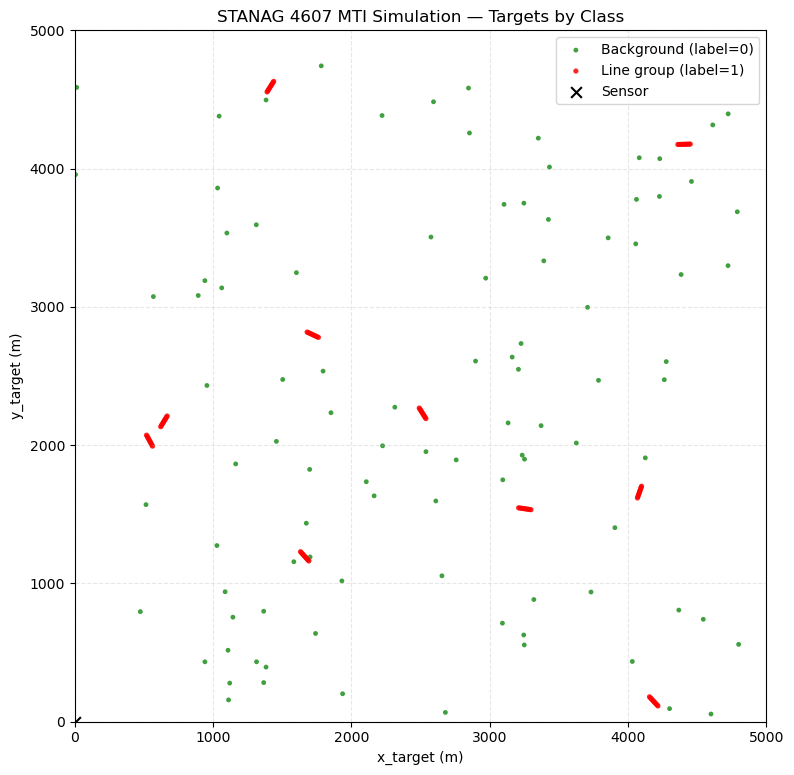

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Option A: if df already exists from the simulation step, skip the next two lines ---
# csv_path = r"C:/Users/charlie.burgwardt/OneDrive - NV5/GMTI/Data/simulatio_1.csv"
# df = pd.read_csv(csv_path)

# Separate classes
bg = df[df['label'] == 0]   # background points (green)
ln = df[df['label'] == 1]   # line-group points (red)

# Create figure
plt.figure(figsize=(8, 8))

# Plot targets
plt.scatter(bg['x_target'], bg['y_target'], s=12, c='green', alpha=0.75, edgecolors='none', label='Background (label=0)')
plt.scatter(ln['x_target'], ln['y_target'], s=14, c='red',   alpha=0.85, edgecolors='none', label='Line group (label=1)')

# Plot the (fixed) sensor position as a reference
# (All rows have the same sensor position; we can read from the first row)
xs, ys = float(df['x_sensor'].iloc[0]), float(df['y_sensor'].iloc[0])
plt.scatter([xs], [ys], s=60, c='black', marker='x', label='Sensor')

# Cosmetics
plt.gca().set_aspect('equal', 'box')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.xlabel('x_target (m)')
plt.ylabel('y_target (m)')
plt.title('STANAG 4607 MTI Simulation — Targets by Class')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()


In [ ]:
#  Plot the inference results
import pandas as pd
import matplotlib.pyplot as plt

# --- Option A: if df already exists from the simulation step, skip the next two lines ---
# csv_path = r"C:/Users/charlie.burgwardt/OneDrive - NV5/GMTI/Data/simulatio_1.csv"
# df = pd.read_csv(csv_path)

csv_path = r"C:\Users\charlie.burgwardt\OneDrive - NV5\GMTI\Data\simulation_2_predictions.csv"
df = pd.read_csv(csv_path)

# Separate classes
bg = df[df['pred'] == 0]   # background points (green)
ln = df[df['pred'] == 1]   # line-group points (red)

# Create figure
plt.figure(figsize=(8, 8))

# Plot targets
plt.scatter(bg['x_target'], bg['y_target'], s=12, c='green', alpha=0.75, edgecolors='none', label='Background (pred=0)')
plt.scatter(ln['x_target'], ln['y_target'], s=14, c='red',   alpha=0.85, edgecolors='none', label='Line group (pred=1)')

# Plot the (fixed) sensor position as a reference
# (All rows have the same sensor position; we can read from the first row)
xs, ys = float(df['x_sensor'].iloc[0]), float(df['y_sensor'].iloc[0])
plt.scatter([xs], [ys], s=60, c='black', marker='x', label='Sensor')

# Cosmetics
plt.gca().set_aspect('equal', 'box')
plt.xlim(0, 5000)
plt.ylim(0, 5000)
plt.xlabel('x_target (m)')
plt.ylabel('y_target (m)')
plt.title('STANAG 4607 MTI Inference — Targets by Class')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper right', frameon=True)

plt.tight_layout()